In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [35]:
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('iris.csv', names=column_names)

In [24]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [25]:
X = df.drop(columns=['species'])
y = df['species']
print("Features shape:", X.shape)

Features shape: (150, 4)


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

In [27]:
cov_matrix = np.cov(X_scaled, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [28]:
print("--- Covariance Matrix ---")
print(pd.DataFrame(cov_matrix, columns=X.columns, index=X.columns))
print("\n" + "="*50 + "\n")

print("--- Eigenvalues ---")
for i, val in enumerate(eigenvalues):
    print(f"Eigenvalue {i+1}: {val:.4f}")
print("\n" + "="*50 + "\n")

print("--- Eigenvectors (Principal Components as Columns) ---")
print(pd.DataFrame(eigenvectors, columns=[f'PC{i+1}' for i in range(4)], index=X.columns))

--- Covariance Matrix ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.006711    -0.110103      0.877605     0.823443
sepal_width      -0.110103     1.006711     -0.423338    -0.358937
petal_length      0.877605    -0.423338      1.006711     0.969219
petal_width       0.823443    -0.358937      0.969219     1.006711


--- Eigenvalues ---
Eigenvalue 1: 2.9304
Eigenvalue 2: 0.9274
Eigenvalue 3: 0.1483
Eigenvalue 4: 0.0207


--- Eigenvectors (Principal Components as Columns) ---
                   PC1       PC2       PC3       PC4
sepal_length  0.522372 -0.372318 -0.721017  0.261996
sepal_width  -0.263355 -0.925556  0.242033 -0.124135
petal_length  0.581254 -0.021095  0.140892 -0.801154
petal_width   0.565611 -0.065416  0.633801  0.523546


In [29]:
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]
k = 2
W = eigenvectors[:, :k] 
X_projected = np.dot(X_scaled, W)
projected_df = pd.DataFrame(data=X_projected, columns=['PC1', 'PC2'])
projected_df['species'] = y.values

In [30]:
print("--- Projection Matrix W (Top-2 Eigenvectors as Columns) ---")
print(pd.DataFrame(W, index=X.columns, columns=['PC1', 'PC2']))
print("\n" + "="*60 + "\n")
print("--- First 5 Rows of the Newly Projected Data ---")
print(projected_df.head())

--- Projection Matrix W (Top-2 Eigenvectors as Columns) ---
                   PC1       PC2
sepal_length  0.522372 -0.372318
sepal_width  -0.263355 -0.925556
petal_length  0.581254 -0.021095
petal_width   0.565611 -0.065416


--- First 5 Rows of the Newly Projected Data ---
        PC1       PC2      species
0 -2.264542 -0.505704  Iris-setosa
1 -2.086426  0.655405  Iris-setosa
2 -2.367950  0.318477  Iris-setosa
3 -2.304197  0.575368  Iris-setosa
4 -2.388777 -0.674767  Iris-setosa


In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['species'] = y.values
pca_df.head()

,Principal Component 1,Principal Component 2,species
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


In [32]:
explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_variance[1]*100:.2f}%")
print(f"Total variance retained: {sum(explained_variance)*100:.2f}%")

Variance explained by PC1: 72.77%
Variance explained by PC2: 23.03%
Total variance retained: 95.80%


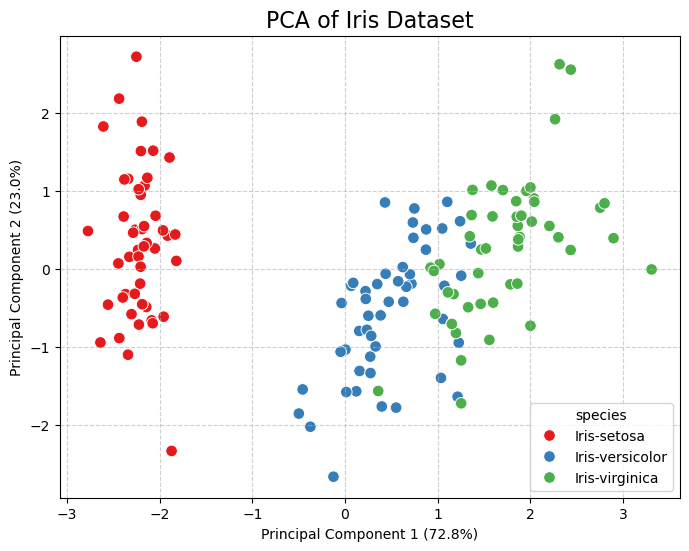

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='species', 
    data=pca_df, 
    palette='Set1',
    s=70
)

plt.title('PCA of Iris Dataset', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [36]:
pca = PCA()
pca.fit(X_scaled)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [37]:
individual_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

In [38]:
print("--- Variance Analysis Summary ---")
for i in range(len(individual_variance)):
    print(f"Principal Component {i+1}:")
    print(f"  -> Captured Variance (Individual): {individual_variance[i]:.2f}%")
    print(f"  -> Cumulative Variance Captured:   {cumulative_variance[i]:.2f}%\n")


--- Variance Analysis Summary ---
Principal Component 1:
  -> Captured Variance (Individual): 72.77%
  -> Cumulative Variance Captured:   72.77%

Principal Component 2:
  -> Captured Variance (Individual): 23.03%
  -> Cumulative Variance Captured:   95.80%

Principal Component 3:
  -> Captured Variance (Individual): 3.68%
  -> Cumulative Variance Captured:   99.48%

Principal Component 4:
  -> Captured Variance (Individual): 0.52%
  -> Cumulative Variance Captured:   100.00%



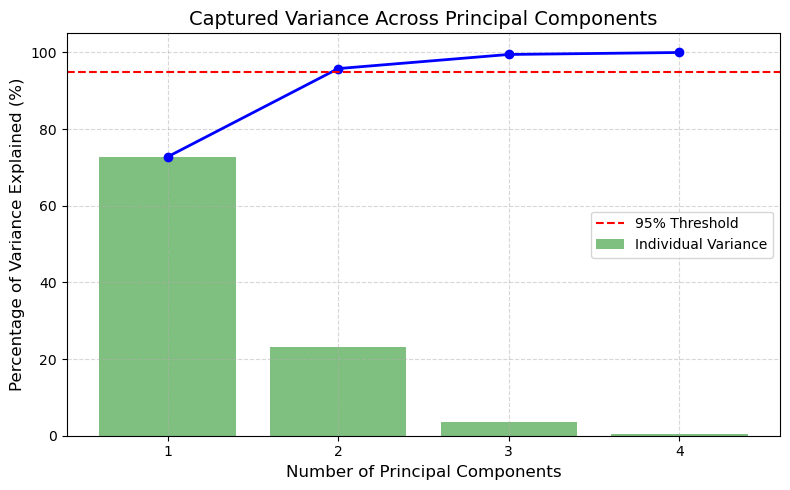

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='b', linestyle='-', linewidth=2)
plt.bar(range(1, len(individual_variance) + 1), individual_variance, alpha=0.5, color='g', label='Individual Variance')
plt.title('Captured Variance Across Principal Components', fontsize=14)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Percentage of Variance Explained (%)', fontsize=12)
plt.xticks(range(1, 5))
plt.axhline(y=95, color='r', linestyle='--', label='95% Threshold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()